In [133]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [134]:
df=pd.read_csv('./data/processed/clean-ames-housing.csv',keep_default_na=False)

In [135]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8.062258,8450,Pave,NA,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NA,Attchd,2000-2010,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NA,NA,NA,0,2,2008,WD,Normal,12.247699
1,2,20,RL,8.944272,9600,Pave,NA,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1950-2000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NA,NA,NA,0,5,2007,WD,Normal,12.109016
2,3,60,RL,8.246211,11250,Pave,NA,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2000-2010,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NA,NA,NA,0,9,2008,WD,Normal,12.317171
3,4,70,RL,7.745967,9550,Pave,NA,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1950-2000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NA,NA,NA,0,2,2006,WD,Abnorml,11.849405
4,5,60,RL,9.165151,14260,Pave,NA,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000-2010,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NA,NA,NA,0,12,2008,WD,Normal,12.429220


In [136]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
x_cat=df[['ExterQual','Neighborhood','KitchenQual']].copy()

In [137]:
x_cat['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [138]:
x_cat['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [139]:
x_cat['KitchenQual'].unique()


array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [140]:
qual_order=['Fa','TA','Gd','Ex' ]
ord_encoder=OrdinalEncoder(categories=[qual_order,qual_order])
x_cat[['ExterQual_enc','KitchenQual_enc']]=ord_encoder.fit_transform(x_cat[['ExterQual','KitchenQual']])

In [141]:
x_dummies=pd.get_dummies(x_cat['Neighborhood'],prefix='nbhd',drop_first=True,)

In [142]:
x=pd.concat([
    x_cat[['ExterQual_enc','KitchenQual_enc']],
    df[['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF' ]],
    x_dummies],axis=1
)

In [143]:
x.head()

,ExterQual_enc,KitchenQual_enc,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,nbhd_Blueste,nbhd_BrDale,nbhd_BrkSide,nbhd_ClearCr,nbhd_CollgCr,nbhd_Crawfor,nbhd_Edwards,nbhd_Gilbert,nbhd_IDOTRR,nbhd_MeadowV,nbhd_Mitchel,nbhd_NAmes,nbhd_NPkVill,nbhd_NWAmes,nbhd_NoRidge,nbhd_NridgHt,nbhd_OldTown,nbhd_SWISU,nbhd_Sawyer,nbhd_SawyerW,nbhd_Somerst,nbhd_StoneBr,nbhd_Timber,nbhd_Veenker
0,2.0,2.0,7,1710,2,856,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,1.0,1.0,6,1262,2,1262,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,2.0,2.0,7,1786,2,920,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1.0,2.0,7,1717,3,756,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,2.0,2.0,8,2198,3,1145,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [144]:
y=df['SalePrice'].copy()

In [145]:
from sklearn.preprocessing import StandardScaler
x_train_ols,x_test_ols,y_train_ols,y_test_ols=train_test_split(x,y,test_size=0.2,random_state=39)
x_train_ols=x_train_ols.reset_index(drop=True)
x_test_ols=x_test_ols.reset_index(drop=True)
y_train_ols=y_train_ols.reset_index(drop=True)
y_test_ols=y_test_ols.reset_index(drop=True)

sds=StandardScaler()
x_train_ols=sds.fit_transform(x_train_ols)
x_test_ols=sds.transform(x_test_ols)
x_train_ols=pd.DataFrame(x_train_ols,columns=x.columns)
x_test_ols=pd.DataFrame(x_test_ols,columns=x.columns)


In [146]:
x_train_ols=sm.add_constant(x_train_ols)
model=sm.OLS(y_train_ols,x_train_ols).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.880
Method:                 Least Squares   F-statistic:                     284.3
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        12:55:53   Log-Likelihood:                 676.68
No. Observations:                1163   AIC:                            -1291.
Df Residuals:                    1132   BIC:                            -1135.
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              12.0332      0.004   29

In [147]:
from sklearn.metrics import r2_score
x_test_ols = sm.add_constant(x_test_ols, has_constant='add')
y_pred_ols = model.predict(sm.add_constant(x_test_ols))
r2=r2_score(y_test_ols,y_pred_ols)
print(f'R2 score on test set: {r2:.4f}')
adj_r2=1-(1-r2)*(len(y_test_ols)-1)/(len(y_test_ols)-x_test_ols.shape[1]-1)
print(f'Adjusted R2 score on test set: {adj_r2:.4f}')

R2 score on test set: 0.8097
Adjusted R2 score on test set: 0.7870


In [148]:
df.select_dtypes(include='object').columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='object')

In [149]:
df.select_dtypes(include='number').columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [150]:
df['MSSubClass']=df['MSSubClass'].astype('object')

### Features Classification

In [151]:
numeric_features=['LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond' , 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']


ExtKitHeat_features=['ExterQual', 'KitchenQual','ExterCond','HeatingQC']
ExtKitHeat_qual=['Po','Fa', 'TA','Gd', 'Ex']

LotShape_feature=['LotShape']
LotShape_order=['Reg', 'IR1', 'IR2', 'IR3']

BsFpGarPol_features=['BsmtQual','FireplaceQu','GarageQual','PoolQC','BsmtCond','GarageCond']
BsFpGarPol_qual=['NA','Po','Fa', 'TA','Gd', 'Ex']

bsmt_exposure_fetaure=['BsmtExposure']
bsmt_exposure_order=['No', 'NA', 'Mn', 'Av', 'Gd']

bsmt_finish_features=[ 'BsmtFinType1','BsmtFinType2']
bsmt_finish_order=['NA', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']

functional_feature=['Functional']
functional_order=['Sal','Sev','Maj2','Maj1', 'Mod','Min2','Min1','Typ']

grage_finish_feature=['GarageFinish']
grage_finish_order=['NA', 'Unf','RFn', 'Fin' ]

paveddrive_feature=['PavedDrive']
paveddrive_order=['N', 'P','Y']

fence_feature=['Fence']
fence_order=['NA', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv']

utilities_feature=['Utilities']
utilities_order=['ELO','NoSeWa','NoSewr','AllPub' ]

landslope_feature=['LandSlope']
landslope_order=['Sev','Mod','Gtl' ]

GarageYrBlt_feature=['GarageYrBlt']
GarageYrBlt_order= ['NA', '1900-1950', '1950-2000', '2000-2010', '2010-2025']



nominal_features=['Condition1', 'Condition2','BldgType','HouseStyle','MSZoning',
       'Street','Alley','LandContour','LotConfig', 'Neighborhood','RoofStyle',
       'RoofMatl','Exterior1st','Exterior2nd','MasVnrType','Foundation','Heating',
       'CentralAir', 'Electrical','MiscFeature','SaleType', 'SaleCondition','GarageType',
       'MSSubClass']

In [152]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
preprocessor=ColumnTransformer([
    ('num',StandardScaler(),numeric_features),
    ('ExtKitHeat',Pipeline([
        ('encode',OrdinalEncoder(categories=[ExtKitHeat_qual]*len(ExtKitHeat_features))),
        ('scale', StandardScaler())]),
        ExtKitHeat_features),
    
    ('LotShape',Pipeline([
        ('encode',OrdinalEncoder(categories=[LotShape_order]*len(LotShape_feature))),
        ('scale',StandardScaler())]),
        LotShape_feature),
    
    ('BsFpGarPol',Pipeline([
        ('encode',OrdinalEncoder(categories=[BsFpGarPol_qual]*len(BsFpGarPol_features))),
        ('scale',StandardScaler())]),
        BsFpGarPol_features),
     
    ('bsmt_exposure',Pipeline([
        ('encode',OrdinalEncoder(categories=[bsmt_exposure_order]*len(bsmt_exposure_fetaure))),
        ('scale',StandardScaler())]),
        bsmt_exposure_fetaure),
    
    ('bsmt_finish',Pipeline([
            ('encode',OrdinalEncoder(categories=[bsmt_finish_order]*len(bsmt_finish_features))),
            ('scale',StandardScaler())]),
            bsmt_finish_features),
    
    ('functional',Pipeline([
                ('encode',OrdinalEncoder(categories=[functional_order]*len(functional_feature))),
                ('scale',StandardScaler())]),
                functional_feature),
    ('grage_finish',Pipeline([
                ('encode',OrdinalEncoder(categories=[grage_finish_order]*len(grage_finish_feature))),
                ('scale',StandardScaler())]),
                grage_finish_feature),
    
    ('paveddrive',Pipeline([
                ('encode',OrdinalEncoder(categories=[paveddrive_order]*len(paveddrive_feature))),
                ('scale',StandardScaler())]),
                paveddrive_feature),
       
    ('fence',Pipeline([
                ('encode',OrdinalEncoder(categories=[fence_order]*len(fence_feature))),
                ('scale',StandardScaler())]),
                fence_feature),
    
    ('utilities',Pipeline([
                ('encode',OrdinalEncoder(categories=[utilities_order]*len(utilities_feature))),
                ('scale',StandardScaler())]),
                utilities_feature),
    
    ('landslope',Pipeline([
                ('encode',OrdinalEncoder(categories=[landslope_order]*len(landslope_feature))),
                ('scale',StandardScaler())]),
                landslope_feature),
    
    ('GarageYrBlt',Pipeline([
                ('encode',OrdinalEncoder(categories=[GarageYrBlt_order]*len(GarageYrBlt_feature))),
                ('scale',StandardScaler())]),
                GarageYrBlt_feature),

    ('nom',OneHotEncoder(drop='first',handle_unknown='ignore'),nominal_features)
])

In [153]:
from sklearn.linear_model import LinearRegression
pipe=Pipeline([
    ('preprocessing',preprocessor),
    ('model',LinearRegression())
])


In [154]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
x=df.drop(columns=['SalePrice'])
y=df['SalePrice']
x_train_pipe,x_test_pipe,y_train_pipe,y_test_pipe=train_test_split(x,y,test_size=0.2,random_state=56)
pipe.fit(x_train_pipe,y_train_pipe)
y_pred=pipe.predict(x_test_pipe)

In [155]:
r2=r2_score(y_test_pipe,y_pred)
print(f'The R2 Score of the Linear Model is {r2}')
n=x_test_pipe.shape[0]
x_train_transformed=preprocessor.fit_transform(x_train_pipe)
x_test_transformed=preprocessor.transform(x_test_pipe)
transformed_columns=pipe.named_steps['preprocessing'].get_feature_names_out()
print(f'The number of features in the transformed dataset is {x_train_transformed.shape[1]}')
p=x_train_transformed.shape[1]
Adj_r2=1-((1-r2)*(n-1)/(n-p-1))
print(f'The Adjusted R2 Score of the Linear Model is {Adj_r2}')

The R2 Score of the Linear Model is 0.9088240995701822
The number of features in the transformed dataset is 206
The Adjusted R2 Score of the Linear Model is 0.6852260580399147


### Feature Selection

#### 1. Filter Methods

In [156]:
x_train_pipe.shape

(1163, 80)

In [157]:
x_train_trnsf_df=pd.DataFrame(data=x_train_transformed,columns=transformed_columns,index=x_train_pipe.index)
x_test_trnsf_df=pd.DataFrame(data=x_test_transformed,columns=transformed_columns,index=x_test_pipe.index)

In [158]:
x_train_trnsf_df.head()

,num__LotFrontage,num__LotArea,num__OverallQual,num__OverallCond,num__MasVnrArea,num__BsmtFinSF1,num__BsmtFinSF2,num__BsmtUnfSF,num__TotalBsmtSF,num__1stFlrSF,num__2ndFlrSF,num__LowQualFinSF,num__GrLivArea,num__BsmtFullBath,num__BsmtHalfBath,num__FullBath,num__HalfBath,num__BedroomAbvGr,num__KitchenAbvGr,num__TotRmsAbvGrd,num__Fireplaces,num__GarageCars,num__GarageArea,num__WoodDeckSF,num__OpenPorchSF,num__EnclosedPorch,num__3SsnPorch,num__ScreenPorch,num__PoolArea,num__MiscVal,ExtKitHeat__ExterQual,ExtKitHeat__KitchenQual,ExtKitHeat__ExterCond,ExtKitHeat__HeatingQC,LotShape__LotShape,BsFpGarPol__BsmtQual,BsFpGarPol__FireplaceQu,BsFpGarPol__GarageQual,BsFpGarPol__PoolQC,BsFpGarPol__BsmtCond,BsFpGarPol__GarageCond,bsmt_exposure__BsmtExposure,bsmt_finish__BsmtFinType1,bsmt_finish__BsmtFinType2,functional__Functional,grage_finish__GarageFinish,paveddrive__PavedDrive,fence__Fence,utilities__Utilities,landslope__LandSlope,GarageYrBlt__GarageYrBlt,nom__Condition1_Feedr,nom__Condition1_Norm,nom__Condition1_PosA,nom__Condition1_PosN,nom__Condition1_RRAe,nom__Condition1_RRAn,nom__Condition1_RRNe,nom__Condition1_RRNn,nom__Condition2_Feedr,nom__Condition2_Norm,nom__Condition2_PosA,nom__Condition2_PosN,nom__Condition2_RRAe,nom__Condition2_RRAn,nom__Condition2_RRNn,nom__BldgType_2fmCon,nom__BldgType_Duplex,nom__BldgType_Twnhs,nom__BldgType_TwnhsE,nom__HouseStyle_1.5Unf,nom__HouseStyle_1Story,nom__HouseStyle_2.5Fin,nom__HouseStyle_2.5Unf,nom__HouseStyle_2Story,nom__HouseStyle_SFoyer,nom__HouseStyle_SLvl,nom__MSZoning_FV,nom__MSZoning_RH,nom__MSZoning_RL,nom__MSZoning_RM,nom__Street_Pave,nom__Alley_NA,nom__Alley_Pave,nom__LandContour_HLS,nom__LandContour_Low,nom__LandContour_Lvl,nom__LotConfig_CulDSac,nom__LotConfig_FR2,nom__LotConfig_FR3,nom__LotConfig_Inside,nom__Neighborhood_Blueste,nom__Neighborhood_BrDale,nom__Neighborhood_BrkSide,nom__Neighborhood_ClearCr,nom__Neighborhood_CollgCr,nom__Neighborhood_Crawfor,nom__Neighborhood_Edwards,nom__Neighborhood_Gilbert,nom__Neighborhood_IDOTRR,nom__Neighborhood_MeadowV,nom__Neighborhood_Mitchel,nom__Neighborhood_NAmes,nom__Neighborhood_NPkVill,nom__Neighborhood_NWAmes,nom__Neighborhood_NoRidge,nom__Neighborhood_NridgHt,nom__Neighborhood_OldTown,nom__Neighborhood_SWISU,nom__Neighborhood_Sawyer,nom__Neighborhood_SawyerW,nom__Neighborhood_Somerst,nom__Neighborhood_StoneBr,nom__Neighborhood_Timber,nom__Neighborhood_Veenker,nom__RoofStyle_Gable,nom__RoofStyle_Gambrel,nom__RoofStyle_Hip,nom__RoofStyle_Mansard,nom__RoofStyle_Shed,nom__RoofMatl_Membran,nom__RoofMatl_Metal,nom__RoofMatl_Roll,nom__RoofMatl_Tar&Grv,nom__RoofMatl_WdShake,nom__RoofMatl_WdShngl,nom__Exterior1st_AsphShn,nom__Exterior1st_BrkComm,nom__Exterior1st_BrkFace,nom__Exterior1st_CemntBd,nom__Exterior1st_HdBoard,nom__Exterior1st_ImStucc,nom__Exterior1st_MetalSd,nom__Exterior1st_Plywood,nom__Exterior1st_Stone,nom__Exterior1st_Stucco,nom__Exterior1st_VinylSd,nom__Exterior1st_Wd Sdng,nom__Exterior1st_WdShing,nom__Exterior2nd_AsphShn,nom__Exterior2nd_Brk Cmn,nom__Exterior2nd_BrkFace,nom__Exterior2nd_CmentBd,nom__Exterior2nd_HdBoard,nom__Exterior2nd_ImStucc,nom__Exterior2nd_MetalSd,nom__Exterior2nd_Other,nom__Exterior2nd_Plywood,nom__Exterior2nd_Stone,nom__Exterior2nd_Stucco,nom__Exterior2nd_VinylSd,nom__Exterior2nd_Wd Sdng,nom__Exterior2nd_Wd Shng,nom__MasVnrType_BrkFace,nom__MasVnrType_None,nom__MasVnrType_Stone,nom__Foundation_CBlock,nom__Foundation_PConc,nom__Foundation_Slab,nom__Foundation_Stone,nom__Foundation_Wood,nom__Heating_GasW,nom__Heating_Grav,nom__Heating_Wall,nom__CentralAir_Y,nom__Electrical_FuseF,nom__Electrical_FuseP,nom__Electrical_Mix,nom__Electrical_SBrkr,nom__MiscFeature_NA,nom__MiscFeature_Othr,nom__MiscFeature_Shed,nom__MiscFeature_TenC,nom__SaleType_CWD,nom__SaleType_Con,nom__SaleType_ConLD,nom__SaleType_ConLI,nom__SaleType_ConLw,nom__SaleType_New,nom__SaleType_Oth,nom__SaleType_WD,nom__SaleCondition_AdjLand,nom__SaleCondition_Alloca,nom__SaleCondition_Family,nom__SaleCondition_Normal,nom__SaleCondition_Partial,nom__Gar

##### i) Duplicated Features

In [159]:
x_train_trnsf_df.T.duplicated().value_counts()


False    205
True       1
Name: count, dtype: int64

In [160]:
x_train_trnsf_df.columns[x_train_trnsf_df.T.duplicated(keep=False)]

Index(['nom__BldgType_Duplex', 'nom__MSSubClass_90'], dtype='object')

In [161]:
x_train_trnsf_df=x_train_trnsf_df.drop(columns=['nom__MSSubClass_90'])
x_test_trnsf_df=x_test_trnsf_df.drop(columns=['nom__MSSubClass_90'])
print(x_train_trnsf_df.shape)
print(x_test_trnsf_df.shape)

(1163, 205)
(291, 205)


##### ii) Varience Threshold

In [162]:
from sklearn.feature_selection import VarianceThreshold
for t in [0.01, 0.002, 0.001,  0.00085911,0.00085910 ]:
    Vt=VarianceThreshold(threshold=t)
    Vt.fit(x_train_trnsf_df)
    
    print(f'Threshold:{t} -> {sum(Vt.get_support())} features Survive')

Threshold:0.01 -> 149 features Survive
Threshold:0.002 -> 180 features Survive
Threshold:0.001 -> 190 features Survive
Threshold:0.00085911 -> 190 features Survive
Threshold:0.0008591 -> 205 features Survive


**Finding:** changing the threshold by 0.00000001 (0.00085910 → 
0.00085911) caused 16 features to drop simultaneously. This extreme 
sensitivity shows a large cluster of features sits at nearly identical 
variance values — there is no stable, principled cutoff point to 
choose here.

**Reasoning:** our numeric and ordinal features are already 
StandardScaled (mean=0, variance≈1), which makes variance an 
unreliable signal of feature usefulness at this stage — nearly all 
scaled columns show similar variance regardless of their actual 
predictive value. A threshold aggressive enough to catch genuinely 
low-information one-hot columns also risks discarding rare-but-meaningful 
categories (e.g., SaleCondition_Partial, which Lasso later identifies 
as informative).

**Decision:** Variance Threshold is skipped. We proceed directly to 
correlation-based filtering and embedded methods (Lasso), which 
evaluate feature relevance relative to the target rather than in 
isolation.

##### iii) Correlation Threshold

**feature-to-feature correlation**

In [163]:
corr_matrix = x_train_pipe[numeric_features].corr().abs()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle=corr_matrix.where(mask)

In [164]:
high_corr_pairs=[(col , row, upper_triangle.loc[col,row])
                 for col in upper_triangle.columns
                 for row in upper_triangle.index
                 if pd.notna(upper_triangle.loc[col,row]) and upper_triangle.loc[col,row]>0.8 ]

In [165]:
high_corr_pairs

[('GrLivArea', 'TotRmsAbvGrd', np.float64(0.8346179206262369)),
 ('GarageCars', 'GarageArea', np.float64(0.8870960833744548))]

In [166]:
print(f'The correlation between "GrLivArea" and "SalePrice" is:' ,x_train_pipe['GrLivArea'].corr(y_train_pipe))
print(f'The correlation between "TotRmsAbvGrd" and "SalePrice" is:', x_train_pipe['TotRmsAbvGrd'].corr(y_train_pipe))
print(f'The correlation between "GarageCars" and "SalePrice" is:', x_train_pipe['GarageCars'].corr(y_train_pipe))
print(f'The correlation between "GarageArea" and "SalePrice" is:', x_train_pipe['GarageArea'].corr(y_train_pipe))



The correlation between "GrLivArea" and "SalePrice" is: 0.7137533163385618
The correlation between "TotRmsAbvGrd" and "SalePrice" is: 0.5255102957382185
The correlation between "GarageCars" and "SalePrice" is: 0.6815334110312272
The correlation between "GarageArea" and "SalePrice" is: 0.6561596677033544


In [167]:
x_train_trnsf_df =x_train_trnsf_df.drop(columns=['num__TotRmsAbvGrd','num__GarageArea'])
x_test_trnsf_df =x_test_trnsf_df.drop(columns=['num__TotRmsAbvGrd','num__GarageArea'])

In [168]:
print(f'The new shape of our dataframe is :{x_train_trnsf_df.shape}')
print(f'The new shape of our dataframe is :{x_test_trnsf_df.shape}')

The new shape of our dataframe is :(1163, 203)
The new shape of our dataframe is :(291, 203)


Feature-to-feature correlation was computed on the training data 
(post-preprocessing) to detect redundant feature pairs — two features 
that carry largely the same information.

Two highly correlated pairs were found (threshold: |r| > 0.8):

| Pair | Correlation | Kept | Dropped | Reason |
|---|---|---|---|---|
| GrLivArea / TotRmsAbvGrd | 0.835 | GrLivArea | TotRmsAbvGrd | GrLivArea has stronger correlation with SalePrice (0.714 vs 0.526) |
| GarageCars / GarageArea | 0.887 | GarageCars | GarageArea | GarageCars has stronger correlation with SalePrice (0.682 vs 0.656) |

**Decision rule:** for each highly correlated pair, retain the feature 
with the stronger correlation to the target, drop the other.

`TotRmsAbvGrd` and `GarageArea` were dropped directly from the 
transformed feature set, consistent with how duplicate features were 
handled in the previous step.

**Result:** feature count reduced from 205 → 203 columns 
(train: (1163, 203), test: (291, 203)).

**feature-to-target correlation**

In [175]:
target_corr=x_train_trnsf_df.corrwith(y_train_ols).abs().sort_values(ascending=False)
target_corr_df=target_corr.reset_index()
target_corr_df.columns=['Feature','Corr with target']
target_corr_df.head()

,Feature,Corr with target
0,num__GarageCars,0.104971
1,grage_finish__GarageFinish,0.101077
2,num__OverallQual,0.085918
3,nom__GarageType_NA,0.075217
4,nom__Exterior2nd_AsphShn,0.074781


In [176]:
target_corr_df.tail()

,Feature,Corr with target
198,nom__RoofStyle_Shed,NaN
199,nom__RoofMatl_Roll,NaN
200,nom__Exterior1st_ImStucc,NaN
201,nom__Foundation_Wood,NaN
202,nom__MiscFeature_TenC,NaN


In [177]:
target_corr_df[target_corr_df['Corr with target']>0.01].count()
        

Feature             149
Corr with target    149
dtype: int64

(array([52., 48., 35., 21.,  9., 14., 10.,  5.,  1.,  2.]),
 array([0.00042114, 0.01087609, 0.02133104, 0.03178599, 0.04224093,
        0.05269588, 0.06315083, 0.07360578, 0.08406073, 0.09451568,
        0.10497063]),
 <BarContainer object of 10 artists>)

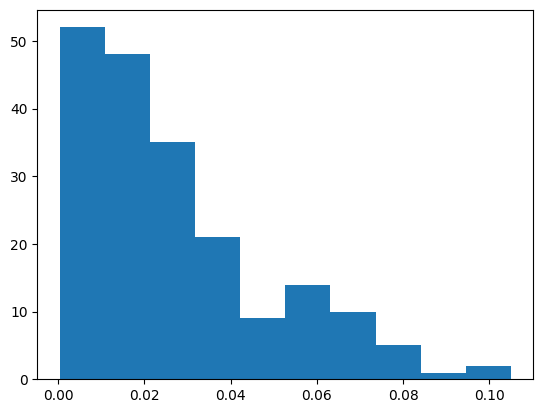

In [174]:
plt.hist(target_corr_df['Corr with target'])




Feature-to-target:Each feature's individual correlation with the target (`SalePrice`) was 
checked to assess raw predictive relevance:


**Finding:** the distribution is steady and skewed — most features 
cluster near zero correlation, with a long downward tail rather than a 
sharp natural cutoff point. Roughly 100 features show |r| > 0.02, while 
48 show |r| < 0.01.

**Limitation acknowledged:** raw correlation is a weak signal for 
individually assessing one-hot encoded columns — a single dummy (e.g. 
one specific Neighborhood category) will naturally show low correlation 
with the target even if the underlying categorical variable as a whole 
carries real signal. Manually picking a hard correlation threshold here 
would be arbitrary and could unfairly penalize categorical features.

**Decision:** rather than manually threshold this correlation value, it 
is used only as a rough sanity check to inform `k` in the more rigorous 
`SelectKBest(score_func=f_regression, k=100)` step next — `f_regression` 
properly evaluates each feature's statistical relationship to a 
continuous target and is better suited to finalizing this cut than 
manual correlation inspection alone.

In [ ]:
coef=pipe.named_steps['model'].coef_


In [ ]:
lasso_coef_df=pd.DataFrame(data={
    'Features':transformed_columns,
    'Coefficients':coef
})
lasso_coef_df[abs(lasso_coef_df['Coefficients'])>0].count()

Features        206
Coefficients    206
dtype: int64

In [ ]:
lasso_coef_df[abs(lasso_coef_df['Coefficients'])>0]

,Features,Coefficients
0,num__LotFrontage,0.011673
1,num__LotArea,0.016753
2,num__OverallQual,0.052756
3,num__OverallCond,0.037907
4,num__MasVnrArea,0.004920
5,num__BsmtFinSF1,0.025740
6,num__BsmtFinSF2,0.006975
7,num__BsmtUnfSF,0.004349
8,num__TotalBsmtSF,0.034683
9,num__1stFlrSF,0.037708
